# **Estatus de la Salud Mental en adultos del municipio más acaudalado de América Látina.**

Reporte técnico del análisis de la salud mental en adultos dentro de la población en edad de trabajar del municipio de San Pedro Garza García.

**Hecho por: Estefania Nájera de la Rosa - estefania.najera@udem.edu a 5 de marzo del 2026.**

In [1]:
# Importar las librerías.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split # Permite implementar la mayoría de modelos.
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
import statsmodels.formula.api as smf

# 1.1 Introducción.

Este siguiente estudio trabaja bajo el dataset utilizado en el proyecto de primer parcial de la clase de Inteligencia Artificial, el cual contiene registros con respecto la salud mental de adultos en edad económicamente activa (18-65 años) que residen en el municipio de San Pedro Garza García, dentro del estado de Nuevo León en México.

Lo que se estará implementando con estos datos es tanto un **Análisis Discriminatorio Lineal (LDA)**, así como un **Árbol de Decisión**.

# 1.2 Objetivo.

El objetivo de este estudio es aplicar el LDA para eventualmente seguir con un árbol de decisión para continuar con la exploración de modelos supervisados de clasificación, los cuales solo pueden brindar 2 salidas con una probabiliad de 0 a 1.

Es importante también mencionar que dentro de las clasificaciones, se implementan clases, análisis respectivo que se hizo dentro del modelo de Regresión Logística, sin embargo, se comentará brevemente más adelante para justificar una sección técnica del código.

# 2.1 Descripción del conjunto de datos.

Como se mencionó anteriormente, el dataset utilizdo es el mismo que el del proyecto del primer parcial, estos provienen del portal de datos abiertos del Gobierno del Estado de Nuevo León dentro del periodo de octubre del 2024 a agosto del 2025.

El dataset seleccionado contiene datos de varios municipios del estado de Nuevo León, por mencionar algunos que pertenecen al área metropólitana como:
* Monterrey.

* San Nicolás de los Garza.

* Santa Catarina.

* General Escobedo.

entre otros.

Sin dejar de lado que también hay datos de municipios aledaños a la metrópoli como lo son:
* Montemorelos.

* Linares.

* Cadereyta Jiménez.

entre otros.

Por cada municipio, es que se tiene registrado por individuo lo siguiente:
* Fecha de la consulta.

* Número de identificación de la consulta.

* Básicos de la persona como edad, sexo, peso y altura.

* Municipio.

* Institución médica dentro del municipio.

* Número de identificación y descripción de su grupo de enfermedad.

In [2]:
# Cargar los datos.
url = 'https://raw.githubusercontent.com/estefaniadelarosa/IA-I/refs/heads/main/P1.%20Regresi%C3%B3n/P1.%20Regresi%C3%B3n/2024_2025_salud_mental.csv'
df = pd.read_csv(url)
print(df.shape)
df.head()

(48224, 14)


,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad
0,02/10/2024,SM_2024_38869,21,0,0,Masculino,82,174,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
1,08/10/2024,SM_2024_38870,21,0,0,Masculino,82,174,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2,08/10/2024,SM_2024_38871,5,0,0,Masculino,21,111,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F919,TRASTORNO DE LA CONDUCTA NO ESPECIFICADO
3,09/10/2024,SM_2024_38872,69,0,0,Masculino,sin valor,sin valor,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F321,EPISODIO DEPRESIVO MODERADO
4,09/10/2024,SM_2024_38873,78,0,0,Masculino,sin valor,sin valor,LINARES,HOSPITAL GENERAL DE LINARES,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F321,EPISODIO DEPRESIVO MODERADO


# 2.2 Preparación y limpieza del conjunto de datos.

Justo como en el proyecto, se filtrarán los datos a que estos sean solamente del municipio de San Pedro Garza García y que dichos contengan a individuos dentro del rango de edad de 18 a 65 años.

In [3]:
df1 = df[df['municipio_unidad_medica'] == 'SAN PEDRO GARZA GARCIA']
print(df1.shape)
df1.head()

(1060, 14)


,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad
2625,02/10/2024,SM_2024_41494,33,0,0,Masculino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F122,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO DEBID...
2626,02/10/2024,SM_2024_41495,53,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2627,02/10/2024,SM_2024_41496,60,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F630,JUEGO PATOLOGICO
2628,04/10/2024,SM_2024_41497,46,0,0,Femenino,70,165,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2629,04/10/2024,SM_2024_41498,47,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION


In [4]:
# Aplicar el filtro de personas dentro del rango de edad de 18 a 65 años.
df2 = df1[(df1['edad'] >= 18) & (df1['edad'] <= 65)]
print(df2.shape)
df2.head()

(720, 14)


,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad
2625,02/10/2024,SM_2024_41494,33,0,0,Masculino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F122,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO DEBID...
2626,02/10/2024,SM_2024_41495,53,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2627,02/10/2024,SM_2024_41496,60,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F630,JUEGO PATOLOGICO
2628,04/10/2024,SM_2024_41497,46,0,0,Femenino,70,165,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION
2629,04/10/2024,SM_2024_41498,47,0,0,Femenino,60,160,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION


Los datos y su tipo que disponemos son los siguientes:
* id_consulta → object

* edad → int64

* sexo → object

* peso → object

* altura → object

* municipio_unidad_medica → object

* institucion_unidad_medica → object

* clave_grupo_ enfermedad → object

* descripcion_grupo_enfermedad → object

* clave_enfermedad → object

* descripcion_enfermedad → object

Por ende, las que se transformarán mediante LabelEncoder son las siguientes:
* sexo

* institucion_unidad_medica

* descripcion_grupo_enfermedad_num

* clave_enfermedad_num

In [5]:
# Convertimos las variables categóricas a categóricas numéricas.
from sklearn.preprocessing import LabelEncoder 

# Aplicamos la transformación.
df2['sexo_num'] = LabelEncoder().fit_transform(df2['sexo'])
df2['institucion_unidad_medica_num'] = LabelEncoder().fit_transform(df2['institucion_unidad_medica'])
df2['descripcion_grupo_enfermedad_num'] = LabelEncoder().fit_transform(df2['descripcion_grupo_enfermedad'])
df2['clave_enfermedad_num'] = LabelEncoder().fit_transform(df2['clave_enfermedad'])
df2['descripcion_enfermedad_num'] = LabelEncoder().fit_transform(df2['descripcion_enfermedad'])

df2.sample(5)

/var/folders/rw/krrrqrzn68j3jq_d4yl8mzk80000gn/T/ipykernel_10700/763801538.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['sexo_num'] = LabelEncoder().fit_transform(df2['sexo'])
/var/folders/rw/krrrqrzn68j3jq_d4yl8mzk80000gn/T/ipykernel_10700/763801538.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['institucion_unidad_medica_num'] = LabelEncoder().fit_transform(df2['institucion_unidad_medica'])
/var/folders/rw/krrrqrzn68j3jq_d4yl8mzk80000gn/T/ipykernel_10700/763801538.py:7: SettingWithCopy

,fecha,id_consulta,edad,edad_meses,edad_dias,sexo,peso,altura,municipio_unidad_medica,institucion_unidad_medica,clave_grupo_ enfermedad,descripcion_grupo_enfermedad,clave_enfermedad,descripcion_enfermedad,sexo_num,institucion_unidad_medica_num,descripcion_grupo_enfermedad_num,clave_enfermedad_num,descripcion_enfermedad_num
23330,31/03/2025,SM_2025_10466,42,0,0,Femenino,54,158,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F411,TRASTORNO DE ANSIEDAD GENERALIZADA,0,1,1,31,29
32281,16/05/2025,SM_2025_19417,54,0,0,Femenino,66.6,152,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,XXI,FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y ...,Z630,PROBLEMAS EN LA RELACION ENTRE ESPOSOS O PAREJA,0,1,0,46,16
11234,05/12/2024,SM_2024_50103,62,0,0,Femenino,61.1,149,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION,0,1,1,32,38
36867,13/06/2025,SM_2025_24003,25,0,0,Masculino,80,170,SAN PEDRO GARZA GARCIA,CENTRO COMUNITARIO DE SALUD MENTAL Y ADICCIONE...,V,TRASTORNOS MENTALES Y DEL COMPORTAMIENTO,F412,TRASTORNO MIXTO DE ANSIEDAD Y DEPRESION,1,0,1,32,38
32315,27/05/2025,SM_2025_19451,22,0,0,Femenino,65,160,SAN PEDRO GARZA GARCIA,CENTRO DE SALUD CON SERVICIOS AMPLIADOS SAN PE...,XXI,FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y ...,Z634,PROBLEMAS RELACIONADOS CON LA DESAPARICION O M...,0,1,0,50,22


Se eliminarán del dataset las variables siguientes:
* edad_meses

* edad_dias

Ya que estas solo contienen 0 como registro, no nos sirve para nada y solo genera ruido.

In [6]:
df2 = df2.drop(columns=['edad_meses', 'edad_dias'])

De igual forma, al tener variables de peso y altura respectivas, se puede unir ambas como una sola variable nueva, siendo esta la de IMC donde se crea dicha variable bajo la operación para encontrar este dato.

In [7]:
# Convertir peso y altura a enteros.
df2['peso'] = df2['peso'].astype(float)
df2['altura'] = df2['altura'].astype(float)

# Verificar.
print(df2.dtypes[['peso','altura']])

peso      float64
altura    float64
dtype: object


In [8]:
# Convertir altura a metros.
df2['altura_m'] = df2['altura'] / 100
# IMC.
df2['IMC'] = df2['peso'] / (df2['altura_m']**2)

# 3.1 Partición de los datos.

Vale la pena mencionar que a diferencia del proyecto y de la Regresión Logística realizadas anteriormente, se tenia como las variables independientes a las siguientes:
* edad

* sexo_num

* institucion_unidad_medica_num

* descripcion_enfermedad_num

Sin embargo, como vamos a estar manejando el LDA, dicho modelo genera sus separaciones lineales según la distribución de los datos donde se espera que los mismos no tengan una relación directa; en el caso de la variable **descripcion_enfermedad_num**, esta tiene una relación en que es un subconjunto de la variable independiente de **descripcion_grupo_enfermedad_num**, es decir, va a existir un sesgo entre las divisiones y estas segundas basicamente no se podrán realizar.

A esto se le llama **Data Leakage** donde según Mucci (2025), esto recae en un caso de **contaminación de datos externos**, en el cual la fusión de datos externos con datos de entrenamiento puede generar predicciones sesgadas o inexactas ya que estos datos externos pueden contener información directa o indirecta sobre la variable objetivo - es justamente lo que sucede y se explicó.

In [9]:
# Definimos entrada y salida.
X = df2[['edad', 'sexo_num', 'institucion_unidad_medica_num']]
y = df2['descripcion_grupo_enfermedad_num']
print(X.shape)
print(y.shape)

(720, 3)
(720,)


De igual forma, ahora abordamos el tema de las clases, nuestra variable dependiente presenta las siguientes:

In [10]:
df2['descripcion_grupo_enfermedad'].value_counts()

descripcion_grupo_enfermedad
TRASTORNOS MENTALES Y DEL COMPORTAMIENTO                                             547
FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS SERVICIOS DE SALUD    173
Name: count, dtype: int64

In [11]:
# Para el porcentaje.
df2['descripcion_grupo_enfermedad'].value_counts()/(df2['descripcion_grupo_enfermedad'].value_counts().sum())*100

descripcion_grupo_enfermedad
TRASTORNOS MENTALES Y DEL COMPORTAMIENTO                                             75.972222
FACTORES QUE INFLUYEN EN EL ESTADO DE SALUD Y CONTACTO CON LOS SERVICIOS DE SALUD    24.027778
Name: count, dtype: float64

Se puede observar que existe un desbalance entre las dos clases de la variable dependiente, en dicho estudio de Regresión Logística, se realizaron diversos modelos que implementaban diversas técnicas de balanceo.

Estos son los resultados que se obtuvieron de los modelos desarrollados con sus respectivas técnicas:
* by Default:

    * 86% de aciertos.

    * 0.87 de validación cruzada.

    * G-mean de 0.85.

    * f1-score:
        * 0.75 para 0.

        * 0.91 para 1.

    * AUC: 0.90.

* Balanced:

    * 86% de aciertos.

    * 0.87 de validación cruzada.

    * G-mean de 0.87.

    * f1-score:
        * 0.76 para 0.

        * 0.90 para 1.

    * AUC: 0.89.

* Manual-Balanced:

    * 93% de aciertos.

    * 0.85 de validación cruzada.

    * G-mean de 0.85.

    * f1-score:
        * 0.73 para 0.

        * 0.90 para 1.

    * AUC: 0.90.

* SMOTE:

    * 92% de aciertos.

    * 0.87 de validación cruzada.

    * G-mean de 0.92.

    * f1-score:
        * 0.92 para 0.

        * 0.92 para 1.

    * AUC: 0.90.

Con estos resultados, se concluyó que el mejor modelo es aquel en el que se emplementa la técnica de balanceo de **SMOTE**, el cual inserta datos sintéticos para balancear las clases.

Es por eso que para el LDA y el Árbol, al momento de trabajar con sus datos de entrenamiento, estos se van a preparar con la técnica de SMOTE, una vez sabiendo como se comportan y se equilibran las clases con esta técnica.

Como un extra conceptual al data set y bajo el tema de la clasificación, es que se busca conocer si una persona recae en alguno de los siguientes grupos:
* Trastornos mentales y del comportamiento.

* Factores que influyen en el estado de salud y contacto con los servicios de salud.

Esto para saber si el/la individuo(a) padece una enfermedad como tal que necesita ser tratada profesionalmente (primer grupo) o si solo requiere de una terapia sin necesidar de caer en un tratamiento que necesite ser guiado bajo un especialista.

Comenzamos con la división de datos de entrenamiento y prueba:

In [12]:
# Dividir los tratos en train y test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((576, 3), (144, 3), (576,), (144,))

In [13]:
y_train.value_counts()

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

descripcion_grupo_enfermedad_num
1    438
0    138
Name: count, dtype: int64

**Implementación de SMOTE.**

Es importante mencionar que la X y Y de entrenamiento son aquellas con SMOTE al estar imputando datos sintéticos (por esta técnica) y queremos que el modelo las aprenda para replicar eso en la prueba y así no manipular los resultados; dichas variables de entrenamiento son las usaremos para generar el LDA y el Árbol de Decisión.

In [14]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

**Balanceo después de técnica.**

In [15]:
print(y_train_smote.value_counts())

# 0: Factores influyendo en el estado de salud. 1: Trastorno mental y del comportamiento.

descripcion_grupo_enfermedad_num
0    438
1    438
Name: count, dtype: int64


# 4.1 LDA.

Según IBM (2025), el Análisis Discriminatorio Lineal (LDA) separa las clases con múltiples características a través de la reducción de la dimensionalidad de los datos, además utiliza el teorema de Bayes para clasificar nuevos puntos de datos mediante las probabilidades condicionales.

La versatilidad de LDA se debe a que puede aplicarse en modelos con múltiples clases, a diferencia de la Regresión Logística que se limita la clasificación binaria; por eso, es que este se aplica para mejorar el funcionamiento de otros modelos de clasificación como los Árboles de Decisión o Random Forest.

Para el desarrollo de este modelo, se tomó como guía aquella de Kavlakoglu (s. f.), llamada: "How to implement linear discriminant analysis in Python." publicada en el sitio de IBM. 

1. **Codificar la variable objetivo** (variable dependiente):

In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(y_encoded.shape)

(720,)


2. **Pair Plot**: los mismos tienen el propóstio de ver cómo las características se relacionan entre si.

/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/s

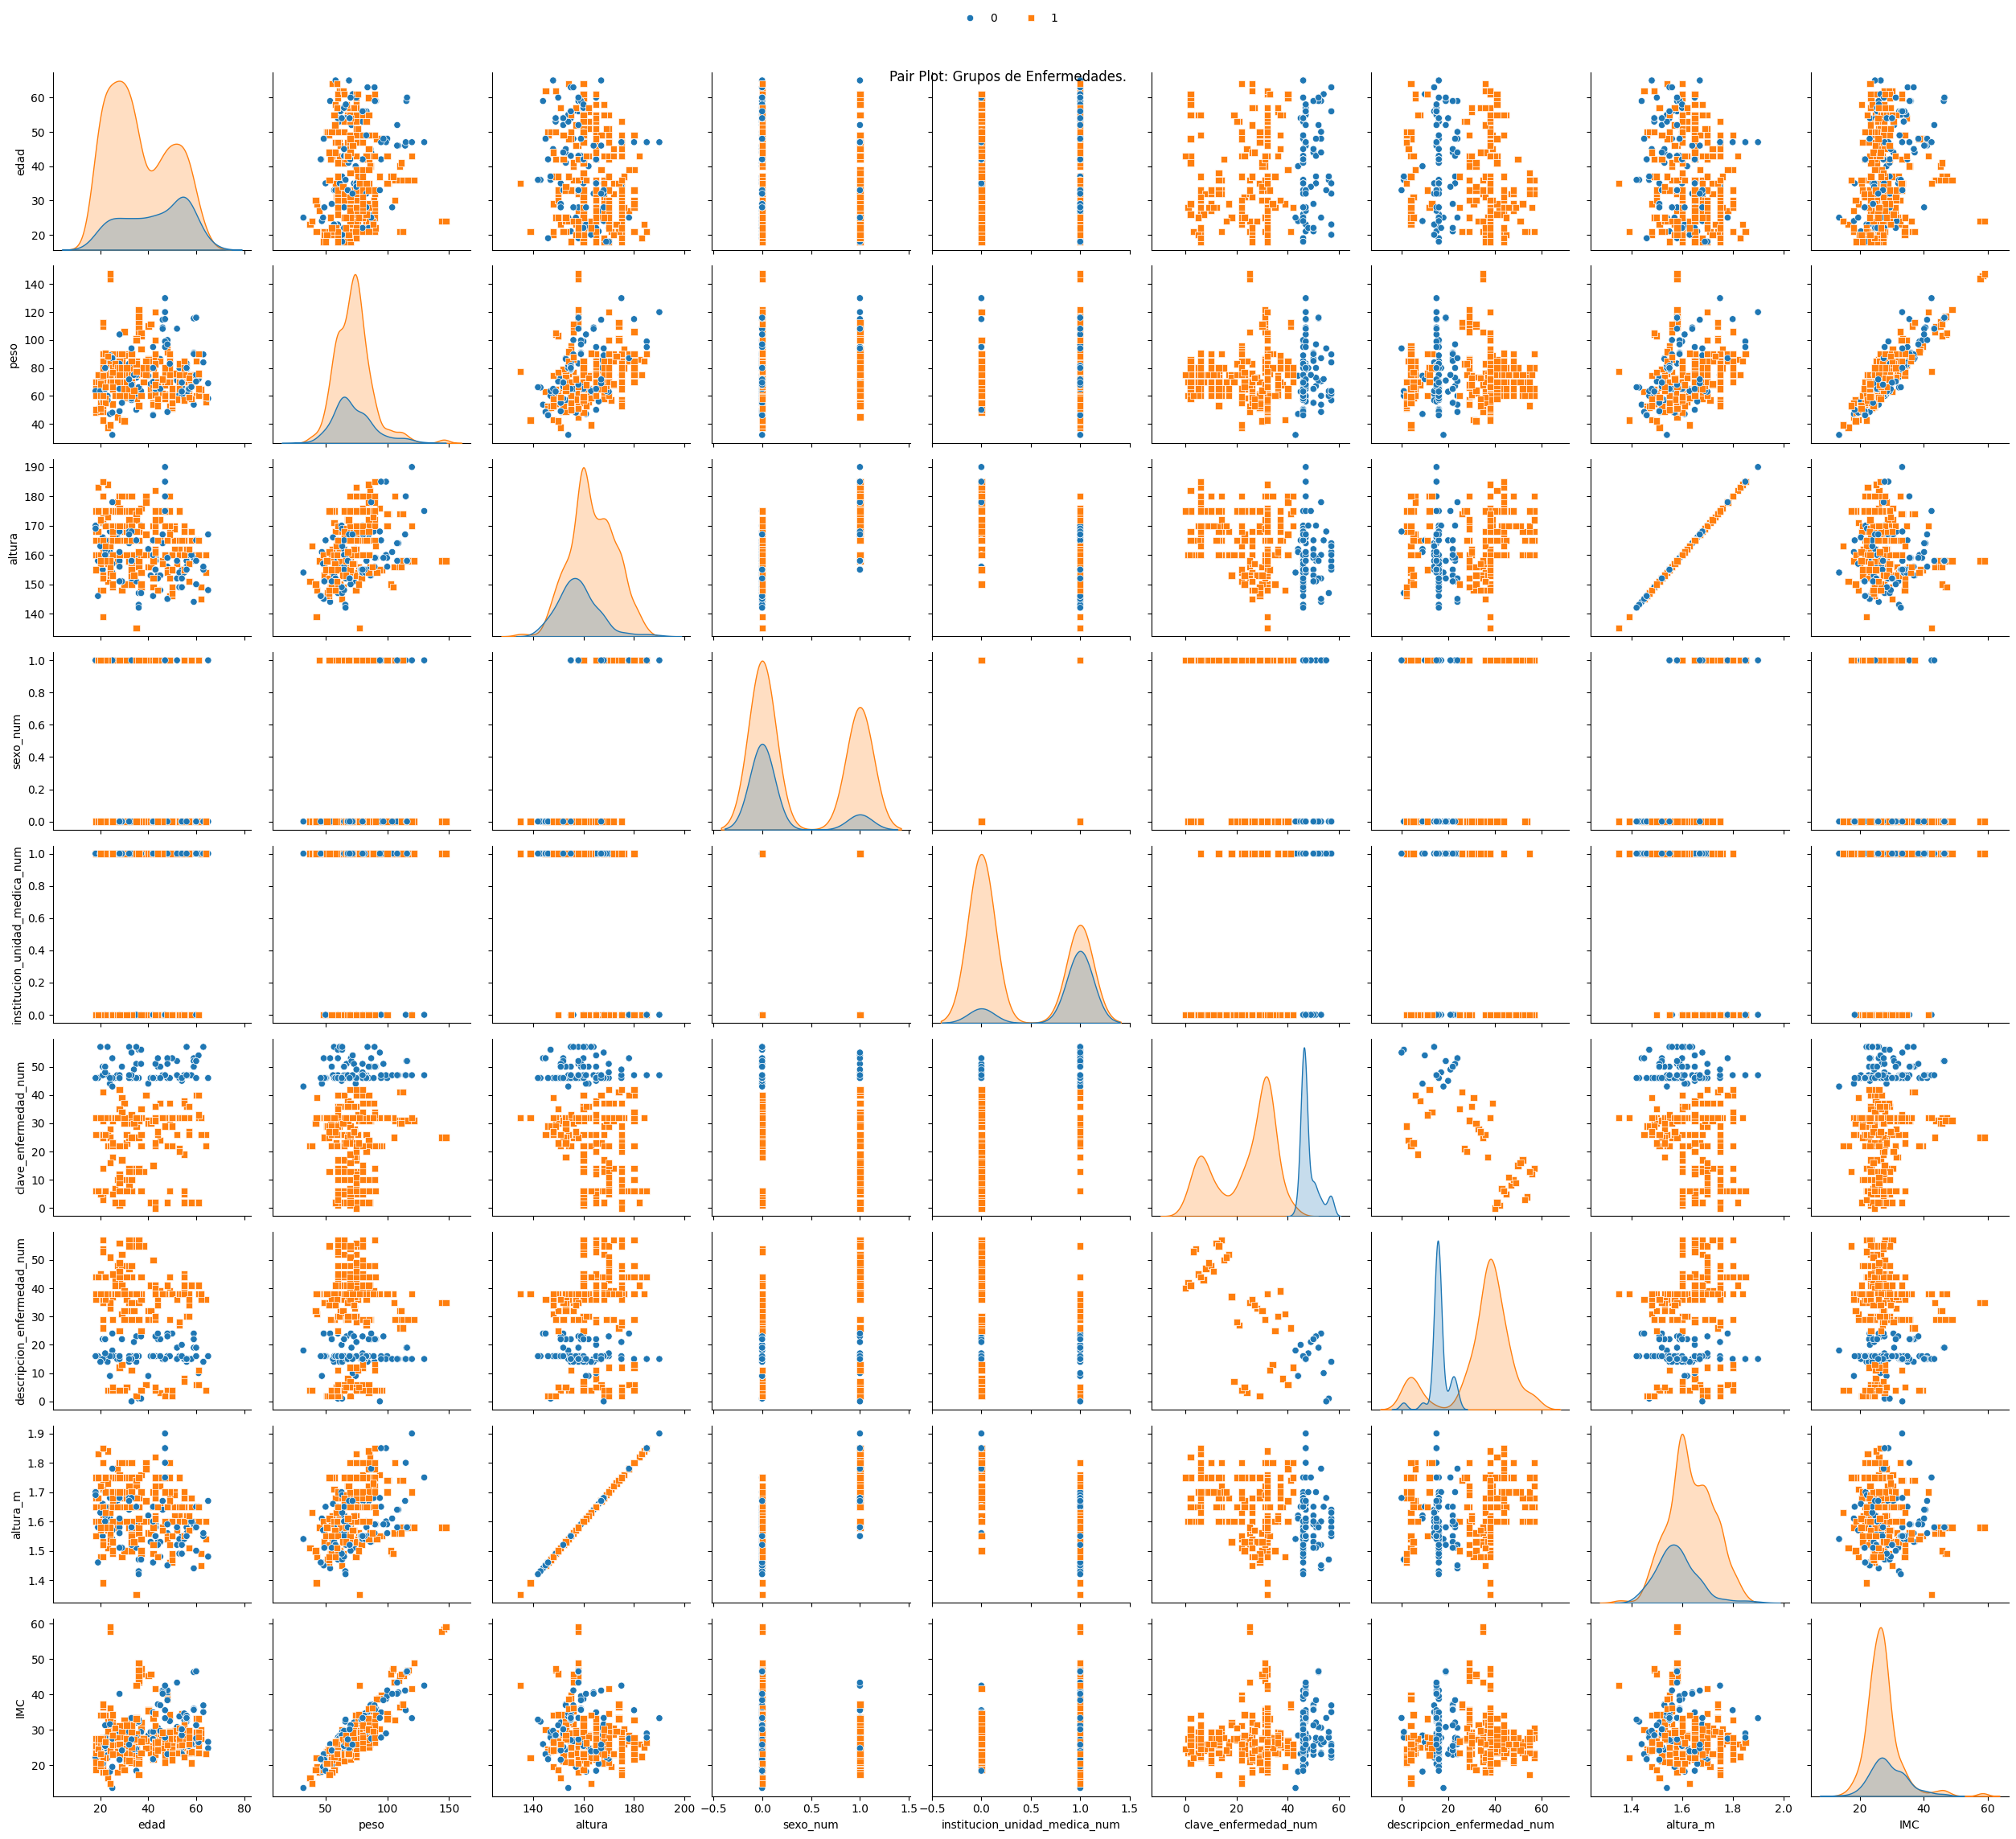

In [17]:
# Create a pair plot to visualize relationships between different features and species.
ax = sns.pairplot(df2, hue = 'descripcion_grupo_enfermedad_num', markers = ["o", "s", "D"])
plt.suptitle("Pair Plot: Grupos de Enfermedades.")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor = (.5, 1), ncol = 3, title = None, frameon = False)
plt.tight_layout()
plt.show()

3. **Histogramas**: estos a diferencia del Pair plot sirven para ver la distribución de las características.

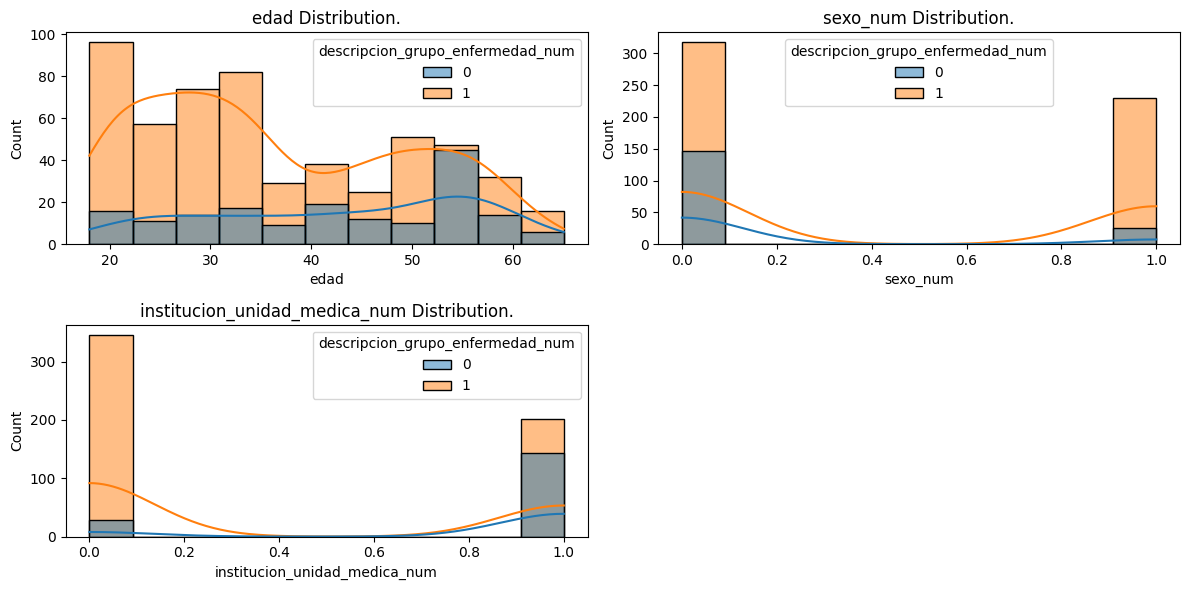

In [18]:
# Visualize the distribution of each feature using histograms.
plt.figure(figsize =( 12, 6))
for i, feature in enumerate(X[:-1]):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data = df2, x = feature, hue = 'descripcion_grupo_enfermedad_num', kde = True)
    plt.title(f'{feature} Distribution.')

plt.tight_layout()
plt.show()

En este caso, se pueden observar diversas cosas:
* En el rango de edad de los 20 a los tardíos 30, la mayoría se encuentran en el grupo 1, es decir, dentro de padecer trastornos mentales y del comportamiento.

    * Dentro de aquí, existe un hecho atípico ya que en los 40 y 50, la mayoría se encuentra en el grupo 0, es decir, dentro de estar viviendo con factores que influyen en su salud mental, no de forma tan grave como los trastornos.

    * Pero en edades más avanzadas, vuelve a repuntar el grupo 1 de los trastornos, esto sería **interesante** de estudiar y cosas así que se descubran de forma visual mediante histogramas u otros gráficos.

4. **Mapa de calor de Correlación**: conocer los coeficientes respectivos entre la relación de 2 variables.

    Rojo presenta una alta correlación, mientras que el Azul presenta una baja correlación.

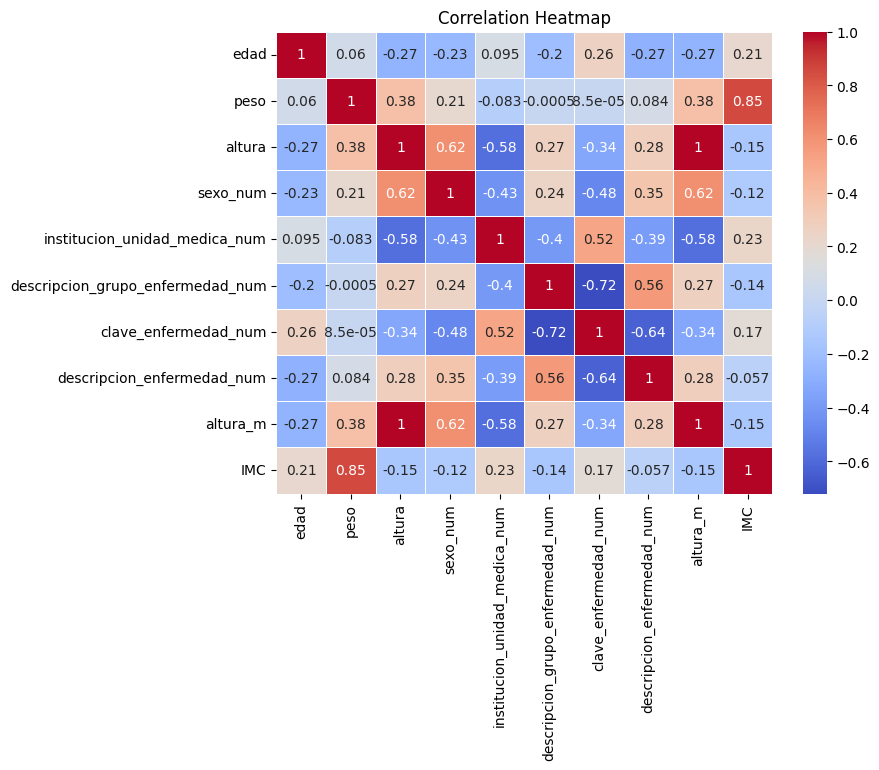

In [19]:
correlation_matrix = df2.corr(numeric_only = True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

Más adelante, al momento de implementar LDA, se tiene que establecer un número de componentes, en el caso de este dataset, solo se tiene que incorporar 1 componente ya que solo vamos a estar tratando dos clases.

In [20]:
# Verificación de n_components = 1 siend 2 clases.
print(np.unique(y_train))
print(len(np.unique(y_train)))

[0 1]
2


5. **LDA**: implementación del modelo gracias a la librería importada anteriormente de sklearn.discriminant_analysis que contiene el LinearDiscriminantAnalysis.

In [21]:
# Apply Linear Discriminant Analysis.
lda = LinearDiscriminantAnalysis(n_components = 1)
X_train_lda = lda.fit_transform(X_train_smote, y_train_smote)
X_test_lda = lda.transform(X_test)

5. **Histograma**: este histograma por si mismo nos muestra la distribución de casa clase a lo largo del LDA, podemos observar claramente cómo se delimitaron las regiones en respectivo lado izquierdo y lado derecho.
* Lado izquierdo: clase 0 - Factores influyendo en el estado de salud. 

* Lado derecho: clase 1 - Trastorno mental y del comportamiento.

Ahora, ¿por qué lo visualizamos con un histograma dicha distribución lineal?
* Esto es debido a que estamos trabajando en 1D, es decir, que estamos bajo una dimensión, por lo que no podemos generar gráficos que se extiendan de las barras.

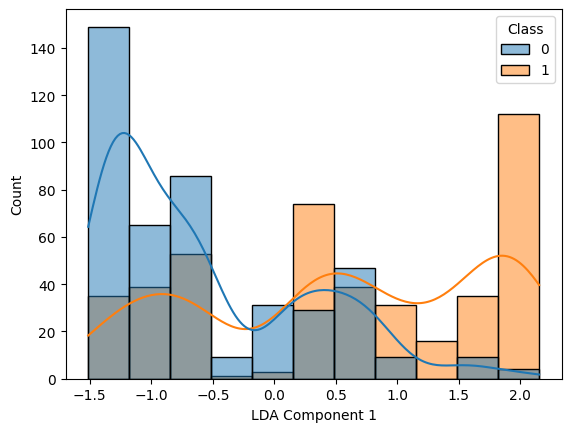

In [22]:
tmp_Df = pd.DataFrame(X_train_lda, columns = ['LDA Component 1'])
tmp_Df['Class'] = y_train_smote.values  

# Grafica.
sns.histplot(data = tmp_Df, x = 'LDA Component 1', hue = 'Class', kde = True)
plt.show()

In [23]:
print(tmp_Df.head())

   LDA Component 1  Class
0        -0.571684      0
1        -1.299334      0
2         0.177260      1
3        -1.449144      1
4         1.296899      1


¡Listo! con esto ya hemos contruido el LDA que nos delimita las regiones y nos ayudará a construir el Árbol de Decisión ya con todo balanceado y ordenado.

# 5.1 Árbol de Decisión.

Según Madhavan & Sturdevant (s. f.), un Árbol de Decisión usa los datos de entrenamiento para generar reglas que se utilizan para la eventual predicción. Dependiendo de los valores dentro del entrenamiento, es que el modelo forma su árbol.

Para el desarrollo de este otro modelo, se tomó como guía aquella de la lectura interactiva: "L2.4 Árboles de decisión.ipynb" de la clase de Inteligencia Artificial.

Anteriormente ya dividimos los datos para desarrollar el árbol, por lo que empezaremos con lo siguiente:
1. **Generar árbol**: esto mediante la librería de sklearn (seguimos trabajando con los datos de entrenamiento con SMOTE).

In [24]:
from sklearn.tree import DecisionTreeClassifier as DTC
tree_smote = DTC().fit(X_train_smote, y_train_smote)

2. **Visualizar el árbol**: igualmente con la librería de sklearn con la función de plot_tree.

[Text(0.4680059523809524, 0.96875, 'institucion_unidad_medica_num <= 0.5\ngini = 0.5\nsamples = 876\nvalue = [438, 438]'),
 Text(0.2222222222222222, 0.90625, 'sexo_num <= 0.5\ngini = 0.38\nsamples = 381\nvalue = [97, 284]'),
 Text(0.3451140873015873, 0.9375, 'True  '),
 Text(0.09523809523809523, 0.84375, 'edad <= 21.5\ngini = 0.484\nsamples = 205\nvalue = [84, 121]'),
 Text(0.07936507936507936, 0.78125, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.1111111111111111, 0.78125, 'edad <= 49.5\ngini = 0.494\nsamples = 188\nvalue = [84, 104]'),
 Text(0.047619047619047616, 0.71875, 'edad <= 24.5\ngini = 0.498\nsamples = 136\nvalue = [72, 64]'),
 Text(0.031746031746031744, 0.65625, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.06349206349206349, 0.65625, 'edad <= 27.5\ngini = 0.5\nsamples = 129\nvalue = [65, 64]'),
 Text(0.031746031746031744, 0.59375, 'edad <= 25.5\ngini = 0.172\nsamples = 21\nvalue = [2, 19]'),
 Text(0.015873015873015872, 0.53125, 'gini = 0.408\nsamples = 7\nval

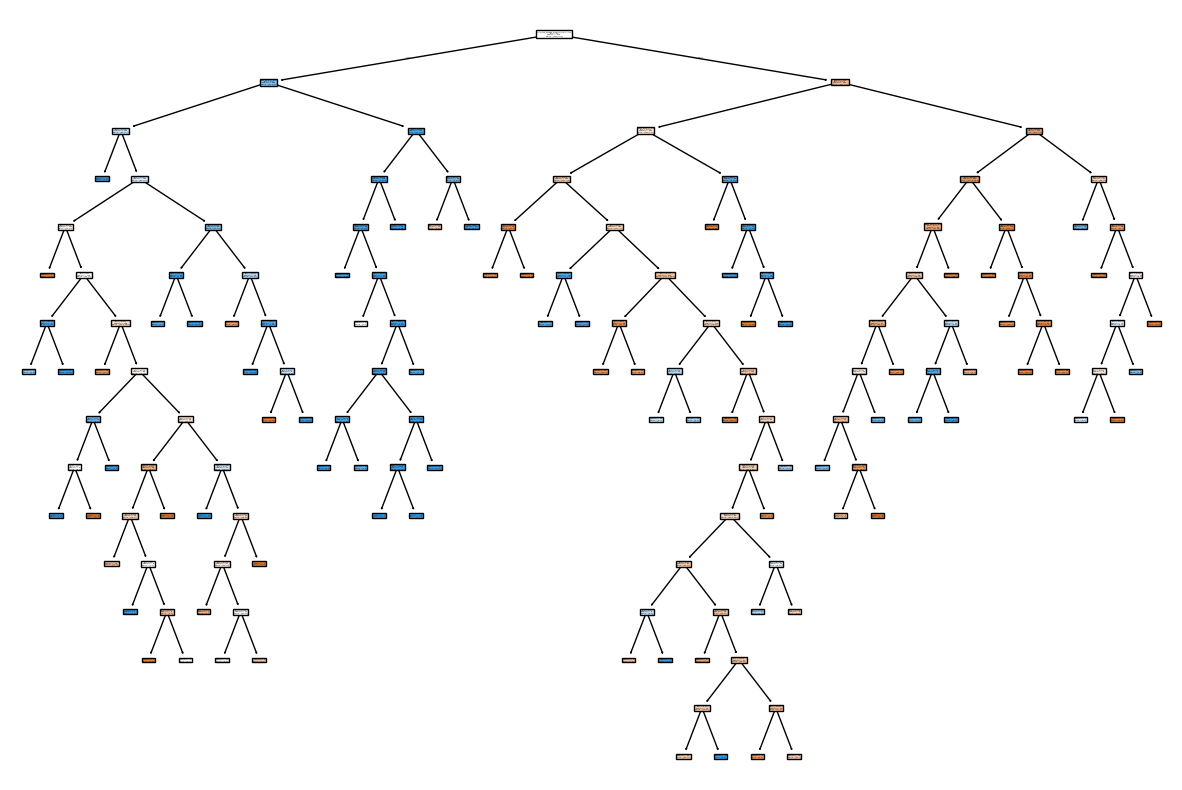

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(tree_smote, filled = True, feature_names = X_train_smote.columns)

El árbol generado cuenta con dos datos muy interesantes:
* Su profundidad (longitud vertical), es de 15.

* Cuenta con 78 hojas.

Esto nos ayuda a dimensionar que es un árbol complejo respectivo al tamaño del dataset.

In [26]:
print(tree_smote.tree_.max_depth)

15


In [27]:
print(tree_smote.get_n_leaves())

78


3. **Métricas**: aquí evaluaremos dos aspectos:

    * Accuracy: aciertos totales (1 - positivos reales y 0 - negativos reales).

    * f1-score: promedio ponderado de las clases.

In [28]:
from sklearn.metrics import accuracy_score, f1_score
yhat0 = tree_smote.predict(X_test)
acc0 = accuracy_score(y_test, yhat0)
f10 = f1_score(y_test, yhat0, average='weighted')
print("Accuracy inicial: ", acc0)
print("F1-score inicial: ", f10)

Accuracy inicial:  0.8125
F1-score inicial:  0.8179125376992675


* El accuracy del modelo es bueno, obtenemos un valor de 0.81, por lo que se puede concluir que bajo el árbol original se acierta la clasificación un 81%.

* El f1-score del modelo también es bueno, obtenemos el mismo valor de 0.81 y esto viene debido a que estuvimos trabajando la técnica de balanceo de SMOTE, por lo que nuestras clases no tendrán un sesgo hacia una en específico, confirmando lo dicho a un 81%; este resultado hubiera sido muy diferente si no hubieramos balanceado anteriormente, ahí si hubiera existido un f1-score bajo y sesgado.

4. **Matriz de Confusión**: esta primera matriz siendo del árbol inicial.

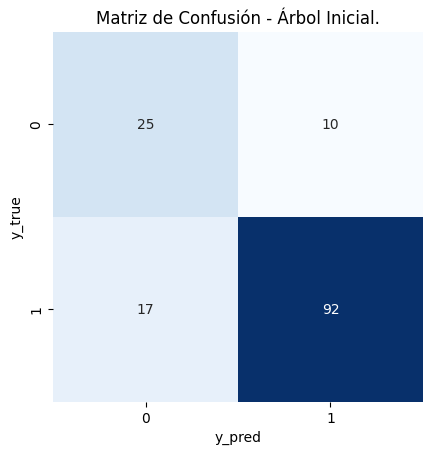

In [29]:
# Matriz de confusión - Árbol inicial.
from sklearn.metrics import confusion_matrix

conf_m = confusion_matrix(y_test, yhat0)
sns.heatmap(conf_m, annot = True, fmt = "d", cmap = "Blues", cbar = False, square = True)
plt.ylabel('y_true')
plt.xlabel('y_pred')
plt.title('Matriz de Confusión - Árbol Inicial.')
plt.show()

Para analizar la Matriz de Confusión del árbol inicial, concluímos lo siguiente:

* 25 + 92 = 117 aciertos.

* Porcentaje de aciertos → 117/144 = 0.81 → 81% (igual que el Accuracy anteriormente mencionado).

* 17 + 10 = 27 errores.

* 144 en total.

# 5.2 Árbol de Decisión Podado.

Proseguimos con el desarrollo del modelo de **Árbol de Decisión**, pero ahora prosiguiendo a podar el mismo.

Según GeeksforGeeks (2026), como los árboles de decisión crecen libremente, tienden a aprender de ruido y de patrones muy específicos de los datos de entrenamiento - estos generan sobreajuste y aquí es cuando entra la poda del mismo árbol, esto tiene los siguientes beneficios:

* Reducir el sobreajuste.

* Mejorar la generalización de datos no vistos.

* Simplifica la estructura del árbol.

* Mejora la interpretabilidad de las reglas de decisión. 

* Mejorar la eficiencia del entrenamiento y la inferencia.

1. **Alpha**: vamos a comenzar creando con StratifiedKFold un sistema de separación de datos con validación cruzada de 4 folds, seguido de un iterador que recorre todos los valores posibles de alpha hasta encontrar el adecuado.
    
    * Alpha es un coeficiente que ayuda para optimar búsquedas.

In [30]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
skf = StratifiedKFold(n_splits = 4)
ccp = np.linspace(0.001, 0.2, 250)
cv_scores = []
for alpha in ccp:
    pruned_tree = DTC(ccp_alpha = alpha, class_weight='balanced')
    cv_scores.append(np.mean(cross_val_score(pruned_tree, X_train_smote, y_train_smote, cv = skf, scoring = 'f1')))

Imprimimos el valor de alpha para ver cuánto nos dió, este será el que se trabajará para la poda.

In [31]:
alpha = ccp[np.argmax(cv_scores)]
print("Best alpha: ", alpha)

Best alpha:  0.001


2. **Generar y visualizar Árbol Podado**:

[Text(0.4253472222222222, 0.9583333333333334, 'institucion_unidad_medica_num <= 0.5\ngini = 0.5\nsamples = 876\nvalue = [438, 438]'),
 Text(0.19791666666666666, 0.875, 'sexo_num <= 0.5\ngini = 0.38\nsamples = 381\nvalue = [97, 284]'),
 Text(0.3116319444444444, 0.9166666666666667, 'True  '),
 Text(0.11805555555555555, 0.7916666666666666, 'edad <= 21.5\ngini = 0.484\nsamples = 205\nvalue = [84, 121]'),
 Text(0.09027777777777778, 0.7083333333333334, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.14583333333333334, 0.7083333333333334, 'edad <= 49.5\ngini = 0.494\nsamples = 188\nvalue = [84, 104]'),
 Text(0.06944444444444445, 0.625, 'edad <= 24.5\ngini = 0.498\nsamples = 136\nvalue = [72, 64]'),
 Text(0.041666666666666664, 0.5416666666666666, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.09722222222222222, 0.5416666666666666, 'edad <= 27.5\ngini = 0.5\nsamples = 129\nvalue = [65, 64]'),
 Text(0.06944444444444445, 0.4583333333333333, 'gini = 0.172\nsamples = 21\nvalue = [2, 19]'

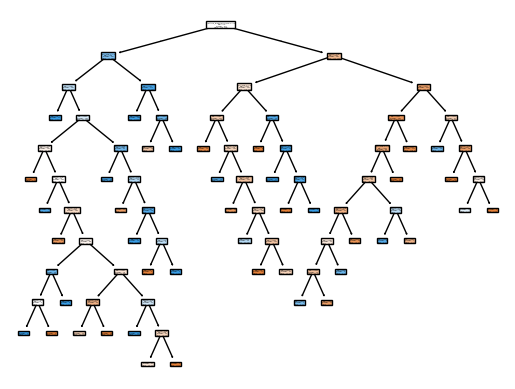

In [32]:
pruned_tree = DTC(ccp_alpha = alpha).fit(X_train_smote, y_train_smote)
plot_tree(pruned_tree, filled = True, feature_names = X_train_smote.columns)

De este otro árbol generado, también vamos a abordar estos dos datos que arroja el mismo: 
* Su profundidad (longitud vertical), es de 11.

* Cuenta con 42 hojas.

In [33]:
print(pruned_tree.tree_.max_depth)

11


In [34]:
print(pruned_tree.get_n_leaves())

42


In [35]:
yhat_p = pruned_tree.predict(X_test)
acc_p = accuracy_score(y_test, yhat_p)
f1_p = f1_score(y_test, yhat_p, average = 'weighted')
print("Accuracy final: ", acc_p)
print("F1-score final: ", f1_p)

Accuracy final:  0.7916666666666666
F1-score final:  0.8018790849673203


* El accuracy del modelo es bueno, obtenemos un valor de 0.79, por lo que se puede concluir que bajo el árbol original se acierta la clasificación un 79%.

* El f1-score del modelo también es bueno, obtenemos un valor de 0.80 y esto viene debido al SMOTE, no se tendrá un sesgo hacia una clase - confirmado en un 80%.

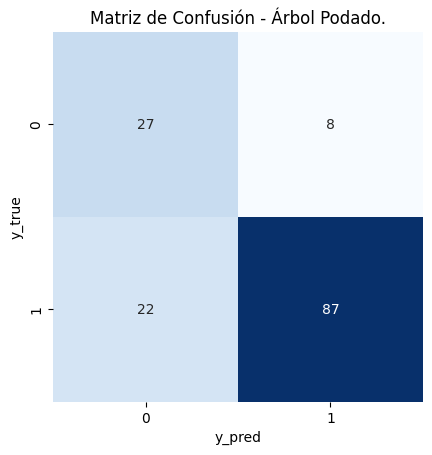

In [36]:
# Matriz de confusión - Árbol inicial
from sklearn.metrics import confusion_matrix

conf_m = confusion_matrix(y_test, yhat_p)
sns.heatmap(conf_m, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.ylabel('y_true')
plt.xlabel('y_pred')
plt.title('Matriz de Confusión - Árbol Podado.')
plt.show()

Para analizar la Matriz de Confusión del árbol podado, concluímos lo siguiente:

* 27 + 87 = 114 aciertos.

* Porcentaje de aciertos → 117/144 = 0.79 → 79% (igual que el Accuracy anteriormente mencionado).

* 22 + 8 = 30 errores.

* 144 en total.

# 6.1 Resultados.

**LDA.**

Para discutir brevemente los resultados de LDA en esta sección respectiva, traemos de vuelta el histograma que nos muestra la distribución de las clases para conocer las delimitaciones de las regiones.

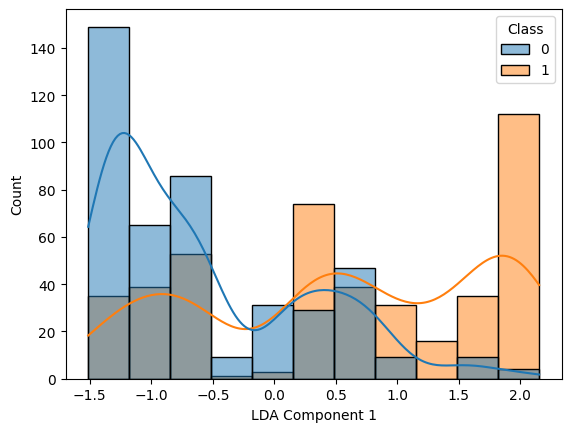

In [40]:
tmp_Df = pd.DataFrame(X_train_lda, columns = ['LDA Component 1'])
tmp_Df['Class'] = y_train_smote.values  

# Grafica.
sns.histplot(data = tmp_Df, x = 'LDA Component 1', hue = 'Class', kde = True)
plt.show()

* Lado izquierdo: clase 0 - Factores influyendo en el estado de salud. 

* Lado derecho: clase 1 - Trastorno mental y del comportamiento.

Nuevamente, ¿por qué lo visualizamos con un histograma dicha distribución lineal?
* Esto es debido a que estamos trabajando en 1D, es decir, que estamos bajo una dimensión, por lo que no podemos generar gráficos que se extiendan de las barras.

**Árbol de Decisión.**

Vamos a comparar y contrastar los resultados de los árboles que generamos, el inicial y el podado desde los enfoques cuantitativos y cualitativos.

**Cuantitativo:**

Árbol Inicial:
* Su profundidad (longitud vertical), es de 15.

* Cuenta con 78 hojas.

* Accuracy: 0.8125

* F1-score: 0.8179125376992675

Árbol podado:
* Su profundidad (longitud vertical), es de 11.

* Cuenta con 42 hojas.

* Accuracy: 0.7916666666666666

* F1-score final:  0.8018790849673203

**Cualitativo:**

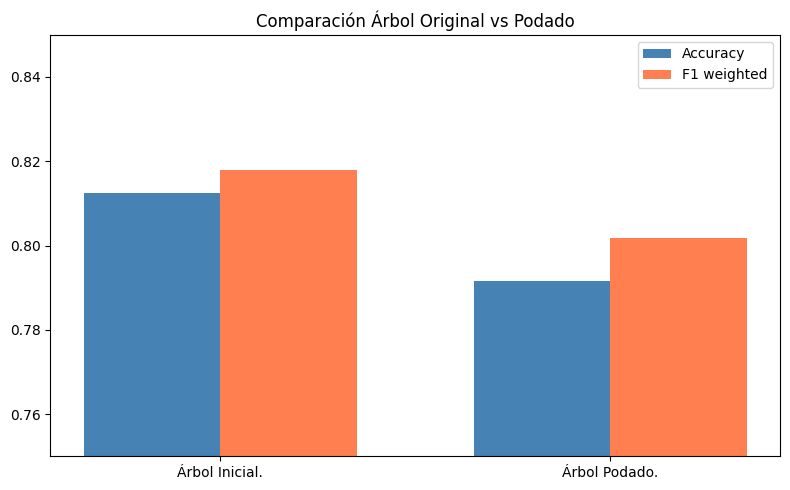

In [ ]:
modelos = ['Árbol Inicial.', 'Árbol Podado.']
accuracies = [0.8125, 0.7917]
f1s = [0.8179, 0.8019]

x = np.arange(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize = (8, 5))
ax.bar(x - width/2, accuracies, width, label = 'Accuracy', color = 'steelblue')
ax.bar(x + width/2, f1s, width, label = 'F1 weighted', color = 'coral')
ax.set_ylim(0.75, 0.85)
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.set_title('Comparación de Árbol Inicial vs Podado.')
plt.tight_layout()
plt.show()

De forma cualitativa, se puede observar fácilmente el desempeño de cada modelo mediante el Accuracy y F1-score.

Normalmente, se espera que el Árbol Podado sea el que presente un mejor desempeño porque reduce el ruido, optimiza el modelo y evita el sobreajuste. Sin embargo, en este caso en especial, como ya habíamos implementado la técnica de balanceo de SMOTE desde un inicio y por ende, al **Árbol Inicial**, podemos concluir que este árbol ya es el **adecuado**, aún y con el hecho que este tenia más profundidad y hojas, lo mismo permitiendo una **buena capacidad de generalización**.

Aún así, vale la pena mencionar que el **Árbol Podado puede ser el adecuado solo si** se busca tener un modelo más **interpretable**, debido a que tiene menor profundidad y menor cantidad de hojas - tomando en cuenta el  **espacio** y **complejidad computacional**.

# 7.1 Discusiones.

Para este estudio, si se tuvieron complicaciones, si es que se pueden decir así ya que no hay nada que Internet no pueda clarificar o ser un apoyo como guía - esto debido a que anteriormente, no se tenía el conocimiento de cómo elaborar un LDA ni un Árbol de Decisión.

Este código es el parteaguas para futuros proyectos donde se presente la situación de utilizar un LDA, que es ideal para escenarios donde tengamos más clases y no se pueda trabajar con Regresión Logística que es binario, es decir, solamente dos clases; claramente implementando todavía lo sabido de las técnicas de balanceo.

El Árbol de Decisión vale la pena conocerlo teóricamente y de forma técnica, cosa que se pudo completar aunque dicho árbol no se utilicé mucho en el mundo real.

# 8.1 Conclusiones.

Para concluir, este estudio aportó en el aprendizaje de esta nueva métrica y modelo de clasificación, donde los mismos se comprendieron de forma tanto teórica como técnica, para poder reonocer situaciones donde los mismos puedan surgir en la lluvia de ideas de qué desarrollar según el problema a resolver para el eventual desarrollo.

En este caso, se siguió tratando lo establecido desde el proyecto de primer parcial y el código de Regresión Logística, aún trabajando con datos relacionados a la salud mental de adultos en las edades económicamente activas, es decir, dentro del rango de 18 a 65 años que específicamente residieran en el municipio de San Pedro Garza García.
Desde la Regresión Logística, se notó que las clases de la variable de interés (variable dependiente) tenían un desbalance, es decir, podría generarse cierto sesgo que tuviera tendencia de inclinarse por aquella clase con más peso, sin embargo, es por eso que se implementaron diversas técnicas de balanceo y se llegó a que la SMOTE era la que rendía un mejor desempeño - este punto se arrastró hacia este otro desarrollo ya que aparte de que seguimos trabajando con los mismos datos, seguimos tratando la clasificación que se caracteriza por las clases, donde es preferible que las mismas se encuentren estables/equitativas para un análisis que sea preciso y confiable al momento de arrojar sus resultados.

# 8.2 Aprendizajes.

Los aprendizajes que se obtuvieron fueron aquellos de desarrollar tanto LDA como el Árbol de Decisión, donde con la ayuda de guías de internet y las guías de clase, es que se pudo realizar cada uno de estos y se pudo analizar los mismos respectivamente para poder comentar este reporte.

Es sumamente enriquecedor realizar modelos nuevos con el autoaprendizaje ya que cada individuo puede ir ajustando lo desarrollado a su manera y a sus expectativas para poder resolver el problema que se le presenta, sin dejar de lado que siempre el entendimiento para la eventual explicación, son lo más importante de tener al momento de seguir guías/tutoriales.

# 8.3 Implicaciones.

Las implicaciones en este estudio sería probablemente el seguir probando otros modelos de clasificación o buscar otras variables de interés donde también se pueda seguir trabajando con un LDA y/o un Árbol de Decisión.

# 8.4 Posibles líneas futuras.

Las posibles líneas futuras y para retroalimentar a las implicaciones, es que probablemente si indagamos más a fondo de los datos, es que podemos encontrar variables que contengan más de dos clases disponibles para justo ahí trabajar con la clasificación y un LDA, volviendo a retomar el balance de clases y ya la eventual implementación de la visualización de las separaciones, si es que las mismas se pueden dividir linealmente, sino, es aquí donde se consideraría QDA que genera separaciones cuadráticas para una recopilación distinta, en este caso, más amplia.

# Referencias.

GeeksforGeeks. (2026). Pruning decision trees. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/pruning-decision-trees/

Kavlakoglu, E. (s. f.). How to implement linear discriminant analysis in Python. IBM Developer. https://developer.ibm.com/tutorials/awb-implementing-linear-discriminant-analysis-python/

Madhavan, S., & Sturdevant, M. (s. f.). Learn classification algorithms using Python and scikit-learn. IBM Developer. Recuperado el 5 de marzo de 2026, de https://developer.ibm.com/tutorials/learn-classification-algorithms-using-python-and-scikit-learn/

Mucci, T. (2025). What is Data Leakage in Machine Learning? Ibm.com. https://www.ibm.com/think/topics/data-leakage-machine-learning

¿Qué es el análisis discriminatorio lineal? (2025). Ibm.com. https://www.ibm.com/mx-es/think/topics/linear-discriminant-analysis


# 9.1 Código de Honor de la Universidad de Monterrey.

Doy mi palabra que he realizado esta actividad con integridad académica.